#### ECCB ISMB info: 
- upset plot für overlap mit cell-type annotation => diverse set of elements not in open chromatin
- first filter the SCREEN IDs down to only get the ones I need => chatGPT => reduce the 

In [12]:
import ast
import pandas as pd
import numpy as np
import yaml
import os

from importlib import reload
import math # check for nan
import matplotlib.pyplot as plt # plt.show()
import seaborn as sns

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [13]:
# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'


list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

In [16]:
# get the SCREEN ID set from the metadata file
metadata_path = "/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/mpra_metadata_format/MPRA_80215.metadata.tsv.gz"
mpra_80k_metadata_df = pd.read_csv(metadata_path, sep='\t', compression='gzip', low_memory=False)

# use safe eval on list
# Apply the safe_eval function to the specified columns
for col in list_columns:
    mpra_80k_metadata_df[col] = mpra_80k_metadata_df[col].apply(safe_eval)

### Common variants for nice biological stories
- ~195 common variants

In [7]:
# NGN2: normalized counts using mpralib
input = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/processing_mpralib/80k_NGN2_normalized_counts.tsv.gz"
input_df = pd.read_csv(input, sep="\t")
input_df

,ID,name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3
0,TTGTTAAAGGGGAGG,GC_DNase_negative_blood:chr10:16877280-1687754...,0.078556,0.134817,0.153148,0.032023,0.113516,0.046527
1,GTTCGTCTAAGTTTG,GC_DNase_negative_blood:chr10:16877280-1687754...,0.549889,0.314573,0.191435,0.368259,0.151355,0.511797
2,GACGCCCAGCCGCTG,GC_DNase_negative_blood:chr10:16877280-1687754...,0.117833,0.134817,0.114861,0.048034,0.075677,0.108563
3,TGTCGTCTCCGCTCG,GC_DNase_negative_blood:chr10:16877280-1687754...,0.078556,0.119837,0.153148,0.192135,0.189194,0.139581
4,TCGCGCATCACGACG,GC_DNase_negative_blood:chr10:16877280-1687754...,0.196389,0.224695,0.076574,0.144102,0.264871,0.155090
...,...,...,...,...,...,...,...,...
6370543,GGGGATGCGGTAGGA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.314222,0.209716,0.268009,0.288203,0.264871,0.170599
6370544,ATGTAAAGACCCCCC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.196389,0.314573,0.306296,0.400282,0.302710,0.294671
6370545,GATCGACGTTTTTAA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,0.078556,0.224695,0.229722,0.256180,0.189194,0.155090
6370546,ACTATGTTATCCAAC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,NaN,NaN,0.191435,0.176124,0.113516,0.093054


In [ ]:
# input_df.rename(columns={'ID': 'barcode'}, inplace=True)
# output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/test_mpralib_output/80k_NGN2_normalized_counts_renamed_ID2barcode.tsv"
# input_df.to_csv(output_path, sep="\t", index=False)

In [ ]:
input_df_no_duplicates = input_df.drop_duplicates(subset=["name"], keep="first").copy()
input_df_no_duplicates

In [63]:
input_df_no_duplicates['testing'] = 1

In [56]:
# containing "~"
input_df_no_duplicates['name'].str.contains("*", regex=False).sum()

0

In [64]:
variant_map = "/home/kisa/coding/80K_MPRA/server_results/80k_counts_after_metadatafile/unique_id_renamed_variant_region_map_mprasnakeflow_input.tsv.gz"
variant_map_df = pd.read_csv(variant_map, sep="\t")
variant_map_df
print(variant_map_df.shape[0])

# drop name

# rename dna_count_1 to
# variant_map_df_seqs = variant_map_df.merge(mpra_80k_metadata_df[[col_name, col_sequence]], left_on="REF", right_on=col_name, how='left')
variant_map_df_seqs = variant_map_df.merge(input_df_no_duplicates[["name", "testing"]], left_on="REF", right_on="name", how='left')
# rename col_sequence to "ref_sequence"
variant_map_df_seqs = variant_map_df_seqs.rename(columns={"testing": "ref_testing"})
variant_map_df_seqs = variant_map_df_seqs.drop(columns=["name"])
variant_map_df_seqs = variant_map_df_seqs.merge(input_df_no_duplicates[["name", "testing"]], left_on="ALT", right_on="name", how='left')
variant_map_df_seqs = variant_map_df_seqs.rename(columns={"testing": "alt_testing"})
variant_map_df_seqs = variant_map_df_seqs.drop(columns=["name"])
# variant_map_df_seqs = variant_map_df_seqs.merge(variant_bcalm_df[['variant_id', 'adj.P.Val', 'logFC']], left_on="ID", right_on="variant_id", how='left')


47044


In [ ]:
variant_map_df_seqs.shape[0]
variant_map_df_seqs['alt_testing'].isna().sum()

In [ ]:
variant_map_df_seqs.loc[variant_map_df_seqs['alt_testing'].isna() | ]

,ID,REF,ALT,ref_testing,alt_testing
5,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NaN,NaN
25,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NaN,NaN
69,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,1.0,NaN
72,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NaN,NaN
95,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,NaN,NaN
...,...,...,...,...,...
46961,GC_Mendelian_variants:ALT_chr7:156791472C>T|SH...,GC_Mendelian_variants:REF_chr7:156791472C>T|SHH,GC_Mendelian_variants:ALT_chr7:156791472C>T|SH...,NaN,NaN
46969,GC_Mendelian_variants:ALT_chr7:156791472C>G|SH...,GC_Mendelian_variants:REF_chr7:156791472C>G|SHH,GC_Mendelian_variants:ALT_chr7:156791472C>G|SH...,NaN,NaN
46970,GC_Mendelian_variants:ALT_chr7:156791472C>T|SH...,GC_Mendelian_variants:REF_chr7:156791472C>T|SHH,GC_Mendelian_variants:ALT_chr7:156791472C>T|SH...,NaN,NaN
46986,GC_Mendelian_variants:ALT_chr8:11703860G>T|GAT...,GC_Mendelian_variants:REF_chr8:11703860G>T|GATA4,GC_Mendelian_variants:ALT_chr8:11703860G>T|GAT...,1.0,NaN


In [69]:
# this means e.g. "cardiac_neuro_cava_random:ALT_SKI|ENSG00000157933.11|EH38E2778498_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E2778498|1-2194344-T-G" is not in the count data
input_df_no_duplicates.loc[input_df_no_duplicates['name'] == "cardiac_neuro_cava_random:ALT_SKI|ENSG00000157933.11|EH38E2778498_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E2778498|1-2194344-T-G"]
input_df_no_duplicates.loc[input_df_no_duplicates['name'] == "cardiac_neuro_cava_random:ALT_SKI|ENSG00000157933.11|EH38E1311779_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E1311779|1-2308500-C-A"]
input_df_no_duplicates.loc[input_df_no_duplicates['name'] == "cardiac_neuro_cava_random:REF_SKI|ENSG00000157933.11|EH38E1311779_fwd_tile1-1"]

,ID,name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,testing
5838350,AGTAAGAATAAACCG,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,NaN,NaN,NaN,NaN,0.075677,0.031018,1


In [ ]:
# expected number of missing variants:
variant_map_df_seqs['missing'] = variant_map_df_seqs['alt_testing'].isna() | variant_map_df_seqs['ref_testing'].isna()
variant_map_df_seqs['missing'].sum() # 3520

3520

In [78]:
# rename ID to barcode: required for bcalm variant:
# input_df.rename(columns={'ID': 'Barcode'}, inplace=True)
# output_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/test_mpralib_output/80k_NGN2_normalized_counts_renamed_ID2barcode.tsv"
# input_df.to_csv(output_path, sep="\t", index=False)

In [8]:
# read current variant table:
variant_input_name = "NGN2_variants_metadata_bcalm_2025_bbmap_scrambled"
variant_input_name = "NGN2_variants_metadata_bcalm_2025_bbmap_normalized_counts"
variant_info_df = pd.read_csv(config['files']['creating'][variant_input_name], sep="\t")
variant_info_df

variant_info_df_tested = variant_info_df.loc[variant_info_df['ALT'].str.contains("cardiac_neuro_cava_random:")]
variant_info_df_tested # n: 46,374

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random


In [9]:
# read database of AF to variant
gnomad_data_all_variants = pd.read_csv(config['files']['creating']['gnomad_data_all_variants_local'], sep="\t") # 46374
# add gnomad prefix to all the columns
gnomad_data_all_variants.columns = ['gnomad_' + col for col in gnomad_data_all_variants.columns]

gnomad_data_all_variants.columns

Index(['gnomad_header', 'gnomad_chrom', 'gnomad_pos', 'gnomad_ref',
       'gnomad_alt', 'gnomad_AC', 'gnomad_AF', 'gnomad_AF_popmax',
       'gnomad_AF_eas', 'gnomad_AF_nfe', 'gnomad_AF_fin', 'gnomad_AF_afr',
       'gnomad_AF_asj'],
      dtype='object')

In [10]:
gnomad_data_all_variants.columns

Index(['gnomad_header', 'gnomad_chrom', 'gnomad_pos', 'gnomad_ref',
       'gnomad_alt', 'gnomad_AC', 'gnomad_AF', 'gnomad_AF_popmax',
       'gnomad_AF_eas', 'gnomad_AF_nfe', 'gnomad_AF_fin', 'gnomad_AF_afr',
       'gnomad_AF_asj'],
      dtype='object')

In [11]:
# add AF info to variant info
variant_info_df_tested.columns
variant_af_info = variant_info_df_tested.merge(gnomad_data_all_variants[['gnomad_header', 'gnomad_AF', 'gnomad_AC']], left_on="ALT", right_on="gnomad_header", how="inner")
variant_af_info


,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_header,gnomad_AF,gnomad_AC
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.472883,71917.0
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.017203,2617.0
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.000007,1.0
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.000007,1.0
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.047348,7205.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,[44],True,0.514030,-0.243036,0.409652,0.056209,1.000000e+00,0.016824,cardiac_neuro_cava_random,car

In [12]:
variant_af_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_AF', 'gnomad_AC'],
      dtype='object')

In [13]:
# get the list of significant variants with high effect size being common
# add common vs not common
def get_variant_frequency_group(row, col_AF, col_AC):
    AF = row[col_AF]
    AC = row[col_AC]
    if AC == 1:
        return "singleton"
    elif AF >= 0.05:
        return "common"
    elif AF > 0.01:
        return "rare"
    else:
        return "ultra-rare"

variant_af_info['variant_frequency_group'] = variant_af_info.apply(lambda row: get_variant_frequency_group(row, col_AF="gnomad_AF", col_AC="gnomad_AC"), axis=1).copy()
variant_af_info

variant_af_info['is_significant_01'] = variant_af_info['bcalm_variant_effect_adjusted_p_value'] < 0.1


<Axes: >

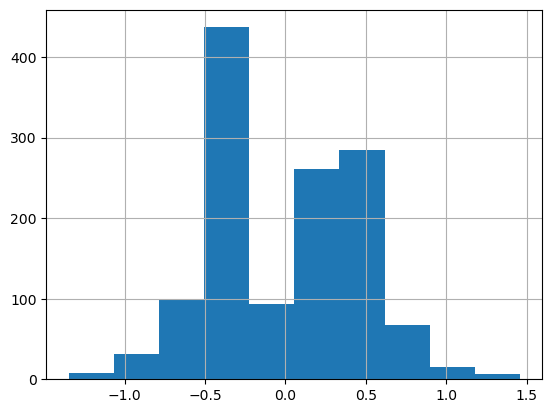

In [14]:
variant_af_info.loc[variant_af_info['is_significant_01']]['bcalm_variant_effect_log_ratio_activity'].hist()


In [ ]:
variant_af_info['high_variant_effect'] = variant_af_info['bcalm_variant_effect_log_ratio_activity'].abs() >=

In [ ]:
variant_af_info

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_header,gnomad_AF,gnomad_AC,variant_frequency_group,is_significant_01,high_variant_effect
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,0.022133,0.131536,5.965362e-07,0.190591,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.472883,71917.0,common,False,False
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.017203,2617.0,rare,False,False
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.000007,1.0,singleton,False,False
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.944787,-0.043372,1.000000,-0.068107,1.000000e+00,-0.072051,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.000007,1.0,singleton,False,False
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.926799,-0.036392,1.000000,0.001944,1.000000e+00,-0.005889,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.047348,7205.0,rare,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.911154,-0.076406,0.015993,0.100370,4.511542e-01,0.065547,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0,singleton,False,False
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.748684,-0.153448,1.000000,-0.080632,9.174673e-02,-0.090558,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0,singleton,False,False
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.989551,0.007846,0.409652,0.056209,4.362900e-01,0.052674,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0,singleton,False,False
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neu

In [177]:
# significant and common sort by effect size

sig_variant_af_info_common = variant_af_info.loc[(variant_af_info['is_significant_01']) & (variant_af_info['variant_frequency_group'] == "common")].copy()
sig_variant_af_info_common # 195
sig_variant_af_info_common_sorted_high = sig_variant_af_info_common.sort_values(by="bcalm_variant_effect_log_ratio_activity", ascending=False)
sig_variant_af_info_common_sorted_low = sig_variant_af_info_common.sort_values(by="bcalm_variant_effect_log_ratio_activity", ascending=True)


In [ ]:
sig_variant_af_info_common

In [102]:
sig_variant_af_info_common_sorted_high

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_header,gnomad_AF,gnomad_AC,variant_frequency_group,is_significant_01
41998,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,cardiac_neuro_cava_random:REF_GATA4|ENSG000001...,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,TATCCTGCCGCCTCTGATTGCAGCTTTAAGAGGTGTAACATTTGAT...,TATCCTGCCGCCTCTGATTGCAGCTTTAAGAGGTGTAACATTTGAT...,[89],True,5.001177e-14,1.420054,6.599687e-02,0.501590,6.343764e-30,1.907606,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_GATA4|ENSG000001...,0.199174,30227.0,common,True
10744,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,cardiac_neuro_cava_random:REF_PKP2|ENSG0000005...,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,ACAGCACCTCACAAGTTAAGTCCCACTGTCTTGGAATTCCAGCCAG...,ACAGCACCTCACAAGTTAAGTCCCACTGTCTTGGAATTCCAGCCAG...,[60],True,1.704626e-07,1.217932,1.212583e-04,-1.367276,1.000000e+00,-0.211115,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_PKP2|ENSG0000005...,0.870416,132385.0,common,True
38800,cardiac_neuro_cava_random:ALT_HIVEP2|ENSG00000...,cardiac_neuro_cava_random:REF_HIVEP2|ENSG00000...,cardiac_neuro_cava_random:ALT_HIVEP2|ENSG00000...,TGGCTTCGCACAGGAGAGCTGGAGAGCTCTTGGTACATATACTGCT...,TGGCTTCGCACAGGAGAGCTGGAGAGCTCTTGGTACATATACTGCT...,[65],True,2.693999e-10,1.071131,1.306308e-07,-1.354085,1.000000e+00,-0.370693,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_HIVEP2|ENSG00000...,0.634270,96376.0,common,True
20890,cardiac_neuro_cava_random:ALT_KANSL1|ENSG00000...,cardiac_neuro_cava_random:REF_KANSL1|ENSG00000...,cardiac_neuro_cava_random:ALT_KANSL1|ENSG00000...,AAAGGGCACGAATTCTCACTGCTTCCCCAAATTAGCTACAAACCAG...,AAAGGGCACGAATTCTCACTGCTTCCCCAAATTAGCTACAAACCAG...,[160],True,2.102699e-12,1.026423,1.000000e+00,-0.296456,1.378569e-10,0.636201,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_KANSL1|ENSG00000...,0.145085,22073.0,common,True
8597,cardiac_neuro_cava_random:ALT_SLC1A2|ENSG00000...,cardiac_neuro_cava_random:REF_SLC1A2|ENSG00000...,cardiac_neuro_cava_random:ALT_SLC1A2|ENSG00000...,TTACCAGATTGCTATTCAGAAAAATGTATTATTTTATGTTCCCATT...,TTACCAGATTGCTATTCAGAAAAATGTATTATTTTATGTTCCCATT...,[198],True,3.962782e-25,0.992709,2.519773e-08,0.607919,3.186222e-74,1.612824,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SLC1A2|ENSG00000...,0.221018,33555.0,common,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5193,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,cardiac_neuro_cava_random:REF_DISC1|ENSG000001...,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,AAGCTTGTGATCCTGAGAAATTTTGTGTTTTCTGTGTTGTCTATAA...,AAGCTTGTGATCCTGAGAAATTTTGTGTTTTCTGTGTTGTCTATAA...,[240],True,8.367472e-31,-1.065467,6.858860e-92,1.384117,1.000000e+00,0.314225,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_DISC1|ENSG000001...,0.668747,101576.0,common,True
24968,cardiac_neuro_cava_random:ALT_NRXN1|ENSG000001...,cardiac_neuro_cava_random:REF_NRXN1|ENSG000001...,cardiac_neuro_cava_random:ALT_NRXN1|ENSG000001...,AATAATGAATCAAAGACACGTCTTGTAAACAATGTCTTGTAATGAT...,AATAATGAATCAAAGACACGTCTTGTAAACAATGTCTTGTAATGAT...,[237],True,2.831671e-21,-1.118239,1.000000e+00,-0.211881,4.425977e-12,-1.262529,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_NRXN1|ENSG000001...,0.086908,13210.0,common,True
36449,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,GTGGAAGATTTTGGAAGTAGTGCCTTATCATGTGAAACCACAGGGC...,GTGGAAGATTTTGGAAGTAGTGCCTTATCATGTGAAACCACAGGGC...,[117],True,3.847016e-19,-1.178731,1.000000e+00,-0.334429,8.655150e-14,-1.398708,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,0.100409,15281.0,common,True
240,cardiac_neuro_cava_r

In [104]:
# read langenberg results:
all_variants_gwas_hits_df = pd.read_csv("/home/kisa/coding/80K_MPRA/collaborations/langenberg/all_variants_80k_MPRA_unique_kircher.gwas_summary.tsv.gz", sep="\t")
all_variants_gwas_hits_df

,spdi,rsid,gwas_rsid,trait_reported,mapped_trait,mapped_trait_efo,study_id,source_gwas_pubmedid,num_reported
0,NC_000001.11:236623909:C:G,rs182203515,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NC_000001.11:236636213:A:G,rs7530563,NaN,NaN,NaN,NaN,NaN,NaN,0
2,NC_000001.11:236660433:C:G,rs1212097797,NaN,NaN,NaN,NaN,NaN,NaN,0
3,NC_000001.11:236688834:G:A,rs79277266,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NC_000001.11:236690725:G:A,rs77549847,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...
9161,NC_000001.11:170666227:A:G,rs501005,rs10919437||rs503706||rs588837||rs608930||rs68...,Arrhythmia||Atrial fibrillation||Atrial fibril...,atrial fibrillation||BMI-adjusted waist circum...,http://www.ebi.ac.uk/efo/EFO_0000275||http://w...,GCST006061||GCST012226||GCST90013707||GCST9001...,29892015||32514122||34021172||34594039||358729...,7
9162,NC_000001.11:170676887:T:G,rs111886775,NaN,NaN,NaN,NaN,NaN,NaN,0
9163,NC_000001.11:170678172:C:A,rs3021340,NaN,NaN,NaN,NaN,NaN,NaN,0
9164,NC_000001.11:170694333:A:G,rs541618,rs10800531,Heel bone mineral density,heel bone mineral density,http://www.ebi.ac.uk/efo/EFO_0009270,GCST006979,30598549,1


#### Investigate overlap of variant overlaping TFBS and the current significant variants
- all are significant
- how many are common? 
variant_frequency_group
ultra-rare    71
singleton     65
common        44
rare          32

In [224]:
import pandas as pd
output_interpration_all_motifs_of_significant_variants = "/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_motifs_overlapping_significant_variants_interpretation_from_h12less_redundant_gene_info.tsv"
output_interpration_all_motifs_of_significant_variants = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/NGN2_variants_tfbs_hit_fimo_h12core_less_local_bitscore.tsv"

combined_fimo_df_overlapping_variants_bitscore_tf_info = pd.read_csv(output_interpration_all_motifs_of_significant_variants, sep="\t", low_memory=False)

# get the alt_ids
all_tfbs_variants_ids = combined_fimo_df_overlapping_variants_bitscore_tf_info['ID'].to_list()
# filter
tfbs_overlap_variant_af_info = variant_af_info.loc[variant_af_info['ID'].isin(all_tfbs_variants_ids)].copy()

In [225]:
variant_af_info

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_header,gnomad_AF,gnomad_AC,variant_frequency_group,is_significant_01
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,NaN,0.000009,1.086994,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.472883,71917.0,common,False
1,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,CCTGATCTGCCCTGTCCGTGACGCTTCTGCTCAGTAGCTGAGCACG...,[181],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.017203,2617.0,rare,False
2,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGAGGC...,CCTCTGGGTGACCCGGAGAACACCAAGGCTGTGAGAAATGGGATGC...,[43],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.000007,1.0,singleton,False
3,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,CCATGCGGTGGCCACAGCCTCGGGTGAGTTCCGGTTCCAAAGTACC...,[116],True,0.979716,0.032099,1.000000,-0.664178,1.000000,-0.675062,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.000007,1.0,singleton,False
4,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,GGACTCCGGTGCCTTCGCATTCCCGAGCTGTTTTTGCTTCTGGAAG...,[205],True,0.929889,-0.053121,1.000000,-0.011245,1.000000,-0.028705,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.047348,7205.0,rare,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46369,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,[64],True,0.954909,0.067305,0.184118,0.538105,0.125401,0.606762,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0,singleton,False
46370,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,[149],True,0.814409,-0.195894,0.102349,-1.000569,0.000484,-1.170305,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0,singleton,False
46371,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,[126],True,0.887483,0.089673,1.000000,0.262415,0.821584,0.344769,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.000009,1.0,singleton,False
46372,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,CCTCTGCCCTCCCTGGCT

In [226]:
tfbs_overlap_variant_af_info.shape[0]

240

In [227]:
combined_fimo_df_overlapping_variants_bitscore_tf_info.loc[~combined_fimo_df_overlapping_variants_bitscore_tf_info['ID'].isin(tfbs_overlap_variant_af_info['ID'].to_list())]


,ID,motif_id,mod_fimo_start,mod_fimo_stop,strand,ALT_name,ALT_q-value,REF_name,REF_q-value,ref_sequence,...,alt_ref_bitscore_diff,TFBS_interpretation,gene_symbol,uniprot_id,uniprot_accession_num,local_ref_bitscore,local_alt_bitscore,alt_ref_local_bitscore_diff,local_bitscore_TFBS_interpretation,mean_abs_alt_ref_bitscore_diff


In [228]:
(tfbs_overlap_variant_af_info['bcalm_variant_effect_adjusted_p_value'] < 0.1 ).sum() # all still significant 212

240

In [229]:
tfbs_overlap_variant_af_info["variant_frequency_group"].value_counts()

variant_frequency_group
ultra-rare    77
singleton     70
common        54
rare          39
Name: count, dtype: int64

In [230]:
# join data:
variant_tfbs_hit_bitscore_info = combined_fimo_df_overlapping_variants_bitscore_tf_info[['ID', 'ALT_name', 'REF_name', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand', 'local_ref_bitscore', 'local_alt_bitscore',
       'alt_ref_local_bitscore_diff', 'mean_abs_alt_ref_bitscore_diff', 'local_bitscore_TFBS_interpretation', 'gene_symbol', 'uniprot_id', 'uniprot_accession_num']].merge(variant_af_info, on="ID", how="inner")

In [241]:
variant_tfbs_hit_bitscore_info.columns

Index(['ID', 'ALT_name', 'REF_name', 'motif_id', 'mod_fimo_start',
       'mod_fimo_stop', 'strand', 'local_ref_bitscore', 'local_alt_bitscore',
       'alt_ref_local_bitscore_diff', 'mean_abs_alt_ref_bitscore_diff',
       'local_bitscore_TFBS_interpretation', 'gene_symbol', 'uniprot_id',
       'uniprot_accession_num', 'REF', 'ALT', 'ref_sequence', 'alt_sequence',
       'variant_pos', 'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_AF', 'gnomad_AC', 'variant_frequency_group',
       'is_significant_01'],
      dtype='object')

In [242]:
significant_common_tfbs_variant_hits = variant_tfbs_hit_bitscore_info.loc[(variant_tfbs_hit_bitscore_info['variant_frequency_group'] == "common") & (variant_tfbs_hit_bitscore_info['is_significant_01']) & (~variant_tfbs_hit_bitscore_info["local_bitscore_TFBS_interpretation"].str.startswith("Ref and Alt have same bit score"))]
high_variant_effect_significant_common_tfbs_variant_hits = significant_common_tfbs_variant_hits.loc[significant_common_tfbs_variant_hits['bcalm_variant_effect_log_ratio_activity'].abs() > 0.7].copy()
high_variant_effect_significant_common_tfbs_variant_hits_sorted = high_variant_effect_significant_common_tfbs_variant_hits.sort_values(by="mean_abs_alt_ref_bitscore_diff", ascending=False)

In [243]:
high_variant_effect_significant_common_tfbs_variant_hits_sorted
high_effect_common_output_path = "high_effect_07_variants_tfbs_hits_no_same_bitscores.tsv"
high_variant_effect_significant_common_tfbs_variant_hits_sorted.to_csv(high_effect_common_output_path, sep="\t", index=False)
# cardiac_neuro_cava_random:ALT_IRX3|ENSG00000177508.12|EH38E3181492_rev_tile1-1_IRX3|ENSG00000177508.12|EH38E3181492|16-54316684-C-T
# cardiac_neuro_cava_random:ALT_IRX3|ENSG00000177508.12|EH38E3181492_rev_tile1-1_IRX3|ENSG00000177508.12|EH38E3181492|16-54316677-A-C => NC_000016.10:54316676:A:C

In [ ]:
significant_common_tfbs_variant_hits

In [234]:
significant_common_tfbs_variant_hits_sorted['ID'].nunique()

54

In [233]:
significant_common_tfbs_variant_hits_sorted.loc[significant_common_tfbs_variant_hits_sorted["gene_symbol"] == "ZNF860"]

,ID,ALT_name,REF_name,motif_id,mod_fimo_start,mod_fimo_stop,strand,local_ref_bitscore,local_alt_bitscore,alt_ref_local_bitscore_diff,...,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_header,gnomad_AF,gnomad_AC,variant_frequency_group,is_significant_01
165,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,NaN,cardiac_neuro_cava_random:REF_IRX3|ENSG0000017...,ZN860.H12CORE.0.P.C,136,152,-,6.9727,5.9955,-0.9772,...,0.000009,0.850076,1.0,0.287336,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,0.311386,47335.0,common,True
164,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,NaN,cardiac_neuro_cava_random:REF_IRX3|ENSG0000017...,ZN860.H12CORE.0.P.C,143,159,-,1.8318,2.8045,0.9727,...,0.000009,0.850076,1.0,-0.393364,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_IRX3|ENSG0000017...,0.406001,61691.0,common,True


In [191]:
variants_with_TFBS_hit_local_bitScore

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,...,is_significant_01,ALT_name,motif_id,local_ref_bitscore,local_alt_bitscore,alt_ref_local_bitscore_diff,mean_abs_alt_ref_bitscore_diff,gene_symbol,uniprot_id,uniprot_accession_num
0,cardiac_neuro_cava_random:ALT_RERE|ENSG0000014...,cardiac_neuro_cava_random:REF_RERE|ENSG0000014...,cardiac_neuro_cava_random:ALT_RERE|ENSG0000014...,ACTCATTGTTTGAGTCAGGAGAATATTGCCTTTCTGTTCTAGATCT...,ACTCATTGTTTGAGTCAGGAGAATATTGCCTTTCTGTTCTAGATCT...,[113],True,0.016135,0.336564,1.000000,...,True,cardiac_neuro_cava_random:ALT_RERE|ENSG0000014...,FOSL2.H12CORE.0.P.B,3.7902,4.7822,0.9920,0.725364,FOSL2,FOSL2_HUMAN,P15408
1,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,cardiac_neuro_cava_random:REF_ECE1|ENSG0000011...,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,TCCAATTGACTGGGTAAGCCTCCTGCCATAGTCAAAGGGCTTCATT...,TCCAATTGACTGGGTAAGCCTCCTGCCATAGTCAAAGGGCTTCATT...,[210],True,0.000185,-1.129114,0.000028,...,True,cardiac_neuro_cava_random:ALT_ECE1|ENSG0000011...,RFX3.H12CORE.1.PS.A,5.9753,5.4166,-0.5587,0.741420,RFX3,RFX3_HUMAN,P48380
2,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,TTGAGGGAGCCCACCTGCCTGTTCCCCACTCCCTCCAGCTGATGCT...,TTGAGGGAGCCCACCTGCCTGTTCCCCACTCCCTCCAGCTGATGCT...,[188],True,0.046544,0.514345,1.000000,...,True,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,ZN787.H12CORE.1.S.C,5.5917,5.5371,-0.0546,0.258075,ZNF787,ZN787_HUMAN,Q6DD87
3,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,GTGCCCTCCCTCTCTTCTTTCCACGTGGCCTTTTCATTTGGCTGTT...,GTGCCCTCCCTCTCTTCTTTCCACGTGGCCTTTTCATTTGGCTGTT...,[225],True,0.039701,-0.456069,1.000000,...,True,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,ANDR.H12CORE.2.P.B,4.8491,5.6997,0.8506,0.569929,AR,ANDR_HUMAN,P10275
4,cardiac_neuro_cava_random:ALT_SFPQ|ENSG0000011...,cardiac_neuro_cava_random:REF_SFPQ|ENSG0000011...,cardiac_neuro_cava_random:ALT_SFPQ|ENSG0000011...,GCTGCAGAGAAGAGAGGGCGCAGGCTGTTTAACTTTGTGCAGTGGA...,GCTGCAGAGAAGAGAGGGCGCAGGCTGTTTAACTTTGTGCAGTGGA...,[87],True,0.000007,0.983012,1.000000,...,True,cardiac_neuro_cava_random:ALT_SFPQ|ENSG0000011...,GLIS1.H12CORE.1.P.B,3.5604,3.5604,0.0000,0.560120,GLIS1,GLIS1_HUMAN,Q8NBF1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,cardiac_neuro_cava_random:REF_FHL1|ENSG0000002...,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,AAATAGTCATAGAACATGGGTCACCTGGCTTCAATTAGTTATGTGA...,AAATAGTCATAGAACATGGGTCACCTGGCTTCAATTAGTTATGTGA...,[226],True,0.009805,0.626305,1.000000,...,True,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,BCL6.H12CORE.0.PSM.A,6.4146,7.3986,0.9840,0.632250,BCL6,BCL6_HUMAN,P41182
184,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,cardiac_neuro_cava_random:REF_FHL1|ENSG0000002...,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,AAATAGTCATAGAACATGGGTCACCTGGCTTCAATTAGTTATGTGA...,AAATAGTCATAGAACATGGGTCACCTGGCTTCAATTAGTTATGTGA...,[226],True,0.009805,0.626305,1.000000,...,True,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,BCL6.H12CORE.0.PSM.A,7.0011,6.7206,-0.2805,0.632250,BCL6,BCL6_HUMAN,P41182
185,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,cardiac_neuro_cava_random:REF_FHL1|ENSG0000002...,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,AAATAGTCATAGAACATGGGTCACCTGGCTTCAATTAGTTATGTGA...,AAATAGTCATAGAACATGGGTCACCTGGCTTCAATTAGTTATGTGA...,[226],True,0.009805,0.626305,1.000000,...,True,cardiac_neuro_cava_random:ALT_FHL1|ENSG0000002...,TEAD1.H12CORE.0.PSM.A,5.8770,6.7400,0.8630,0.903750,TEAD1,TEAD1_HUMAN,P28347
186,cardiac_neuro_cava_random:ALT_MECP2|ENSG000001...,cardiac_neuro_cava_random:REF_MECP2|ENSG000001...,cardiac_neuro_cava_random:ALT_MECP2|

In [223]:
combined_fimo_df_overlapping_variants_bitscore_tf_info.columns

Index(['ID', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand',
       'ALT_name', 'ALT_q-value', 'REF_name', 'REF_q-value', 'ref_sequence',
       'alt_sequence', 'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'ref_bitscore',
       'alt_bitscore', 'alt_ref_bitscore_diff', 'TFBS_interpretation',
       'gene_symbol', 'uniprot_id', 'uniprot_accession_num',
       'local_ref_bitscore', 'local_alt_bitscore',
       'alt_ref_local_bitscore_diff', 'local_bitscore_TFBS_interpretation',
       'mean_abs_alt_ref_bitscore_diff'],
      dtype='object')

In [165]:
variant_af_info.columns

Index(['ID', 'REF', 'ALT', 'ref_sequence', 'alt_sequence', 'variant_pos',
       'bcalm_variant_effect_data_exists',
       'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity',
       'bcalm_reference_adjusted_p_value',
       'bcalm_reference_log_ratio_activity',
       'bcalm_alternative_adjusted_p_value',
       'bcalm_alternative_log_ratio_activity', 'label', 'gnomad_header',
       'gnomad_AF', 'gnomad_AC'],
      dtype='object')

In [187]:
common_tfbs_overlap_variants = variant_af_info.loc[variant_af_info["variant_frequency_group"] == "common"].copy()
common_tfbs_overlap_variants

,ID,REF,ALT,ref_sequence,alt_sequence,variant_pos,bcalm_variant_effect_data_exists,bcalm_variant_effect_adjusted_p_value,bcalm_variant_effect_log_ratio_activity,bcalm_reference_adjusted_p_value,bcalm_reference_log_ratio_activity,bcalm_alternative_adjusted_p_value,bcalm_alternative_log_ratio_activity,label,gnomad_header,gnomad_AF,gnomad_AC,variant_frequency_group,is_significant_01
0,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,GTCCCAGCTCCCCACTGATGTGAAAGGTGGTGGTGAGTTAACAGCT...,[83],False,NaN,NaN,NaN,NaN,0.000009,1.086994,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.472883,71917.0,common,False
14,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,[89],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.202318,30752.0,common,False
15,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,[115],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.240360,36541.0,common,False
16,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,[194],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.448177,68079.0,common,False
17,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,CTGCTGAGGGTCCTCTTTTCCCATCCGGGTGCTGGCGGGACAGGGG...,[234],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.449349,68266.0,common,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46302,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,cardiac_neuro_cava_random:REF_FLNA|ENSG0000019...,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,TGCCTCAGGATGCAAAAGCCACATGGACAGGGCGTGGAGCAAGGAG...,TGCCTCAGGATGCAAAAGCCACATGGACAGGGCGTGGAGCAAGGAG...,[100],False,NaN,NaN,NaN,NaN,NaN,NaN,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_FLNA|ENSG0000019...,0.279373,30895.0,common,False
46321,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AGCAGCATTTGCCTTGGGGTGGGGAGGTTCCCTGGCAATGGATCAG...,AGCAGCATTTGCCTTGGGGTGGGGAGGTTCCCTGGCAATGTATCAG...,[40],True,0.948639,0.054252,1.0,0.069392,1.000000,0.126611,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.330254,36283.0,common,False
46322,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,AGTCATCCACTGCCCCCTGCCCGGTGAAGGGCCCTGAGACCCACCA...,AGTCATCCACTGCCCCCTGCCCGGTGAAGGGCCCTGAGACCCACCA...,[216],True,0.677119,-0.291266,1.0,0.105074,1.000000,-0.145291,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,0.387844,42683.0,common,False
46326,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATAGAATTTAACGATGGACTTCAGGTAGACTTAGTCTGAGTGCAAC...,ATAGAATTTAACGATGGACTTCAGGTAGACTTAGTCTGAGTGCAAC...,[62],True,0.829969,-0.128526,1.0,-0.033213,1.000000,-0.1

In [162]:
combined_fimo_df_overlapping_variants_bitscore_tf_info.columns

Index(['ID', 'motif_id', 'mod_fimo_start', 'mod_fimo_stop', 'strand',
       'ALT_name', 'ALT_q-value', 'REF_name', 'REF_q-value', 'ref_sequence',
       'alt_sequence', 'variant_pos', 'bcalm_variant_effect_adjusted_p_value',
       'bcalm_variant_effect_log_ratio_activity', 'ref_bitscore',
       'alt_bitscore', 'alt_ref_bitscore_diff', 'TFBS_interpretation',
       'gene_symbol', 'uniprot_id', 'uniprot_accession_num'],
      dtype='object')

### Get the TFBS within all sequences according to fimo

In [38]:
error_in_header = ["C_positive_neuron_CD:c1_NA_NA_NA_NA::72hr_top_22-mean_ratio1.9", "C_positive_neuron_CD:c1_NA_NA_NA_NA::72hr_top_152-mean_ratio1.86"]
def get_neuro_ctrls_scrambled_label(name):
    """Checks if the given label names are in the sequence name: somethines sequences are merged => we dont miss any"""
    if name in error_in_header:
        return "error_in_header"
    if "scramble" in name:
        return "scramble_ctrl"
    if "negative_neuron" in name:
        return "negative_neuron_ctrl"
    if "positive_neuron" in name:
        # if not (("C_positive_neuron_CD" in name) | ("C_positive_neuron_NP" in name) | ("C_positive_neuron_MK" in name)):
        #     print("Unexpected")
        return "positive_neuron_ctrl"
    if "cardiac_neuro_cava_random" in name:
        return "cardiac_neuro_cava_random"
    return name.split(":")[0]


In [39]:
# mpra_80k_metadata_df['label'] = mpra_80k_metadata_df['name'].apply(hf.get_label)
mpra_80k_metadata_df['label'] = mpra_80k_metadata_df['name'].apply(get_neuro_ctrls_scrambled_label)
mpra_80k_metadata_df['label'].value_counts()

label
cardiac_neuro_cava_random            73940
MK                                    1897
C_positive_heart_AB                    909
scramble_ctrl                          506
negative_neuron_ctrl                   445
GC_Selvarajan                          358
positive_neuron_ctrl                   292
GC_Vista                               256
C_negative_heart_MK                    231
GC_Mendelian_variants                  209
GC_Kircher                             203
C_SLEA                                 200
GC_Cort_Chengyu                        185
C_positive_heart_CAD                    99
C_positive_heart_MK                     93
GC_Glut_Chengyu                         83
GC_DNase_positive_shuffeled             55
GC_Atrial_fib                           45
GC_GABA_Chengyu                         41
GC_DNase_positive                       41
GC_Mohlke                               38
GC_DNase_negative_blood_shuffeled       19
GC_DNase_negative_brain_shuffeled       16
GC_Li

In [40]:
# filter the sequences:
tested_scramble_neuro_ctrls_lable_names = ["cardiac_neuro_cava_random", "negative_neuron_ctrl", "scramble_ctrl", "positive_neuron_ctrl"]

filtered_mpra_80k_metadata_df = mpra_80k_metadata_df.loc[mpra_80k_metadata_df['label'].isin(tested_scramble_neuro_ctrls_lable_names)].copy()
filtered_mpra_80k_metadata_df.shape[0]

75183

In [41]:
# fimo input cannot handle ":" so new name without ":"
filtered_mpra_80k_metadata_df['fimo_name'] = filtered_mpra_80k_metadata_df['name'].apply(lambda name: name.split(":")[1])
filtered_mpra_80k_metadata_df['fimo_name'].nunique() # 75183


75183

In [42]:
filtered_mpra_80k_metadata_df['category'].value_counts()

category
variant      65115
element       9561
scrambled      507
Name: count, dtype: int64

In [44]:
filtered_mpra_80k_metadata_df.loc[filtered_mpra_80k_metadata_df.duplicated(subset=['fimo_name'], keep=False)]

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,label,fimo_name


In [46]:
tested_scramble_neuro_ctrls_output_path ="/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/80K_tested_neuro_ctrls_scrambled_fimo_input.fa"
hf.write_fasta(filtered_mpra_80k_metadata_df, output_path=tested_scramble_neuro_ctrls_output_path, header=['fimo_name', 'sequence'])

True

In [47]:
filtered_mpra_80k_metadata_df['fimo_name'].to_list()

['SKI|ENSG00000157933.11|EH38E2778476_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778477_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778478_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778480_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778484_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778493_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778511_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778514_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778516_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778523_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778531_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778545_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778607_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778609_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778613_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778628_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E2778631_fwd_tile1-1',
 'SKI|ENSG00000157933.11|EH38E1311708_fwd_tile1-1',
 'SKI|ENSG00

In [ ]:
# call fimo for all sequences => without adapter

# fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_fimo_h12core_less  /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/all_fimo_results/all_variants_fimo_input.fa
# fimo --max-stored-scores 1000000 --o /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/all_neuro_ctrls_scrambled_tested_h13  /home/kisa/coding/80K_MPRA/fimo_data/Pia_generated_h13core/H13CORE_meme_format_clustered.meme /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/80K_tested_neuro_ctrls_scrambled_fimo_input.fa

# "/home/kisa/coding/80K_MPRA/fimo_data/Pia_generated_h13core/H13CORE_meme_format_clustered.meme"

In [ ]:
/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_h13_clustered_all_useful_sequences_neuro_ctrls_scrambled_tested/80K_tested_neuro_ctrls_scrambled_fimo_input.fa

### SCREEN element origin in the assay: 
- In which cell-types are our SCREEN regions open according to SCREEN DNase Read-Normalized signal values

- NOTES: 
- ⁠only xx % of the elements show activity different to scrambled controls within these zy% are cCRE in neurons according to screen.
- ⁠how many percent of all cCREs are within CREs from Neurons?
- ⁠the distribution of ref neuro CREs compared to all CREs
- ⁠within the highly active elements these motifs are enriched
- ⁠single nucleotides can change the transcriptional regulatory effect of these sequences significantly
- ⁠this can be because these sequence changes increase the binding affinitiy of a TFBs with an effect on the transcription
- ⁠one example which was found to be associated with xY according to the gwas catalogue changes the binding affinity of Cz TFBS which is known to be activating/repressing (citation A). This variant has an allele frequency of xy and decreases the transcription of the interacting gene.

In [17]:
mpra_80k_metadata_df_tested = mpra_80k_metadata_df.loc[mpra_80k_metadata_df['name'].str.contains('cardiac_neuro_cava_random')].copy()


In [9]:
# for grouping into active and not active:
ngn2_elements_scrambled = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_scrambled"
# ngn2_elements_scrambled = "undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_scrambled"

ngn2_bcalm_scrambled = pd.read_csv(config['files']['creating'][ngn2_elements_scrambled], sep="\t", low_memory=False)

# Apply the safe_eval function to the specified columns
for col in list_columns:
    ngn2_bcalm_scrambled[col] = ngn2_bcalm_scrambled[col].apply(safe_eval)

ngn2_bcalm_scrambled

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,1.332728e-33,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,1.000000e+00,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,1.614862e-02,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,9.615387e-01,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [6]:
import pandas as pd
ngn2_elements_neuro_ctrls = "NGN2_element_metadata_with_bcalm_2025_04_bbmap_normalized_counts_neuro_ctrl"
# ngn2_elements_neuro_ctrls = "undiffWTC11_element_metadata_with_bcalm_2025_05_bbmap_normalized_counts_neuro_ctrls"

ngn2_bcalm_negative_neuron = pd.read_csv(config['files']['creating'][ngn2_elements_neuro_ctrls], sep="\t", low_memory=False)
ngn2_bcalm_negative_neuron

# Apply the safe_eval function to the specified columns
for col in list_columns:
    ngn2_bcalm_negative_neuron[col] = ngn2_bcalm_negative_neuron[col].apply(safe_eval)

ngn2_bcalm_negative_neuron

,name,sequence,category,class,source,ref,chr,start,end,strand,...,SPDI,allele,info,bcalm_element_adjusted_p_value,bcalm_element_log_ratio_activity,bcalm_data_exists,label,not_shifted_bcalm_element_log_ratio_activity,bcalm_element_log_ratio_activity_z_score_neg_ctrl,bcalm_element_log_ratio_activity_z_score_scrambled_ctrl
0,GC_Mohlke:REF_NC000001.11|159752292|A|G|Mohlke...,ATACATCCTTTAATTTGTTCCTACATCTTGCTTGGATTTTCCCCTG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,159752058.0,159752328.0,+,...,[NC_000001.11:159752292:A:G],[ref],NaN,1.000000e+00,0.002170,True,GC_Mohlke,0.002170,2.425938,0.447914
1,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,TGTGTCTGGTGAGGTTGCTGACACTGCTTTTGGATGAGAGAGAGAG...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159023.0,230159293.0,+,...,[NC_000001.11:230159168:C:T],[ref],NaN,1.000000e+00,-0.005898,True,GC_Mohlke,-0.005898,2.197536,0.239294
2,GC_Mohlke:REF_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,"[NC_000001.11:230159168:C:T, NC_000001.11:2301...","[ref, ref]",NaN,1.000000e+00,0.005348,True,GC_Mohlke,0.005348,2.515917,0.530100
3,GC_Mohlke:ALT_NC000001.11|230158967|C|A|Mohlke...,GTTTACCCAGCCGTGGGAAAGGACGCTGTACCCCTGCCCTATTGGC...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230159136.0,230159406.0,+,...,[NC_000001.11:230159328:TCTTAAAGTGTTCAGCACTCCC:T],[alt],NaN,1.000000e+00,-0.007093,True,GC_Mohlke,-0.007093,2.163688,0.208377
4,GC_Mohlke:REF_NC000001.11|230161389|C|T|Mohlke...,CCTCAACTCTCCACATGCCCCAGTAGCATAGACCAGCTTCCTTACA...,variant,variant negative control,general controls IGVF year 1 design 2023,GRCh38,chr1,230161269.0,230161539.0,+,...,[NC_000001.11:230161389:C:T],[ref],NaN,2.586896e-43,0.184521,True,GC_Mohlke,0.184521,7.588730,5.163559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80210,GC_Glut_Chengyu:Glut|chr12:44940899-44941168|-...,TGTCCAAAAAAAGTAAAAGTCATAACAGAAATTGGATTTCAAATGG...,element,element inactive control,NaN,GRCh38,chr12,44940898.0,44941168.0,-,...,None,None,NaN,1.000000e+00,-0.007241,True,GC_Glut_Chengyu,-0.007241,2.159500,0.204552
80211,GC_Glut_Chengyu:Glut|chr2:212699381-212699650|...,TGTGAGTGCTATAATTGTAACCCTTTATAATTGACAGACATTAATT...,element,element inactive control,NaN,GRCh38,chr2,212699380.0,212699650.0,+,...,None,None,NaN,8.456762e-05,0.030434,True,GC_Glut_Chengyu,0.030434,3.226171,1.178839
80212,GC_Glut_Chengyu:Glut|chr10:26798829-26799098|-...,TTTAATAGGAGTACTATTGAATTTACATTTAATGTAGTTAATGATA...,element,element inactive control,NaN,GRCh38,chr10,26798828.0,26799098.0,-,...,None,None,NaN,2.705467e-13,0.051942,True,GC_Glut_Chengyu,0.051942,3.835118,1.735046
80213,GC_Glut_Chengyu:Glut|chr7:31260964-31261233|+|...,TTTCTTATACTGTATGTTTAAAGATATAGACAATGCATATACAAGT...,element,element inactive control,NaN,GRCh38,chr7,31260963.0,31261233.0,+,...,None,None,NaN,2.536828e-09,0.039459,True,GC_Glut_Chengyu,0.039459,3.481679,1.412218


In [7]:
ngn2_bcalm_negative_neuron.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'not_shifted_bcalm_element_log_ratio_activity',
       'bcalm_element_log_ratio_activity_z_score_neg_ctrl',
       'bcalm_element_log_ratio_activity_z_score_scrambled_ctrl'],
      dtype='object')

In [10]:
col_p_value = "bcalm_element_adjusted_p_value"
col_logFC = "bcalm_element_log_ratio_activity"
# filter for cardiac_neuro_cava_random
ngn2_bcalm_scrambled_tested = ngn2_bcalm_scrambled.loc[ngn2_bcalm_scrambled[col_name].str.contains("cardiac_neuro_cava_random")].copy()
containing_scrambl = ngn2_bcalm_scrambled.loc[ngn2_bcalm_scrambled[col_name].str.contains("scrambl")].copy()

ngn2_bcalm_negative_neuron_tested = ngn2_bcalm_negative_neuron.loc[ngn2_bcalm_negative_neuron[col_name].str.contains("cardiac_neuro_cava_random")].copy()
containing_negative_neuron = ngn2_bcalm_negative_neuron.loc[ngn2_bcalm_negative_neuron[col_name].str.contains("negative_neuron")].copy()

# get significant active group compared to scrambled
high_active = ngn2_bcalm_scrambled_tested.loc[(ngn2_bcalm_scrambled_tested[col_p_value] < 0.1) & (ngn2_bcalm_scrambled_tested[col_logFC] > 0)].copy()
high_active_name = set(high_active[col_name].to_list())

# get significantly less active group compared to scrambled
scramble_less_active = ngn2_bcalm_scrambled_tested.loc[(ngn2_bcalm_scrambled_tested[col_p_value] < 0.1) & (ngn2_bcalm_scrambled_tested[col_logFC] <= 0)].copy()
scramble_less_active_names = set(scramble_less_active[col_name].to_list())

# get with activity and drop the once which are in the scrambled set
negative_control_median = containing_negative_neuron[col_logFC].median()
negative_control_active = ngn2_bcalm_negative_neuron_tested.loc[(ngn2_bcalm_negative_neuron_tested[col_p_value] < 0.1) & (ngn2_bcalm_negative_neuron_tested[col_logFC] > negative_control_median)].copy()
negative_control_active = negative_control_active.loc[~((negative_control_active[col_name].isin(high_active_name)) | (negative_control_active[col_name].isin(scramble_less_active_names)))].copy()
negative_control_active_names = set(negative_control_active[col_name].to_list())


# use one of the element metadata files for the all background
all_tested_names = set(ngn2_bcalm_scrambled.loc[ngn2_bcalm_scrambled['bcalm_data_exists']][col_name].to_list())
# get with no activity
no_activity_group_names = all_tested_names - negative_control_active_names - scramble_less_active_names - high_active_name

In [18]:
# Define conditions
conditions = [
    mpra_80k_metadata_df_tested['name'].isin(high_active_name),
    mpra_80k_metadata_df_tested['name'].isin(scramble_less_active_names),
    mpra_80k_metadata_df_tested['name'].isin(negative_control_active_names),
    mpra_80k_metadata_df_tested['name'].isin(no_activity_group_names)
]

# Define corresponding labels
labels = ['high_active', 'scramble_less_active', 'negative_control_active', 'no_activity']

# Assign values to a new column
mpra_80k_metadata_df_tested['activity_group'] = np.select(conditions, labels, default='no_measurement')


In [19]:
# Define conditions
conditions = [
    ngn2_bcalm_negative_neuron_tested['name'].isin(high_active_name),
    ngn2_bcalm_negative_neuron_tested['name'].isin(scramble_less_active_names),
    ngn2_bcalm_negative_neuron_tested['name'].isin(negative_control_active_names),
    ngn2_bcalm_negative_neuron_tested['name'].isin(no_activity_group_names)
]

# Define corresponding labels
labels = ['high_active', 'scramble_less_active', 'negative_control_active', 'no_activity']

# Assign values to a new column
ngn2_bcalm_negative_neuron_tested['activity_group'] = np.select(conditions, labels, default='no_measurement')

In [20]:
def get_activity_group_name(activity_group):
    if activity_group == "no_activity":
        return "no significant activity"
    if activity_group == "negative_control_active":
        return "increasing activity"
    if activity_group == "high_active":
        return "highly activating"
    if activity_group == "scramble_less_active":
        return "decreasing regulatory activity"

mpra_80k_metadata_df_tested["plot_activity_group"] = mpra_80k_metadata_df_tested["activity_group"].apply(get_activity_group_name)
ngn2_bcalm_negative_neuron_tested["plot_activity_group"] = ngn2_bcalm_negative_neuron_tested["activity_group"].apply(get_activity_group_name)

In [21]:
ngn2_bcalm_negative_neuron_tested["plot_activity_group"].value_counts()

plot_activity_group
no significant activity           56836
increasing activity                7128
highly activating                  2530
decreasing regulatory activity     1747
Name: count, dtype: int64

In [31]:
mpra_80k_metadata_df_tested

,name,sequence,category,class,source,ref,chr,start,end,strand,variant_class,variant_pos,SPDI,allele,info,activity_group,plot_activity_group
2287,cardiac_neuro_cava_random:SKI|ENSG00000157933....,AAGAATACAAGTAACTGATGAATGAAGGGGGCATCTTGTGTCCCCA...,element,test,NaN,GRCh38,chr1,2181843.0,2182113.0,+,None,None,None,None,NaN,no_activity,no significant activity
2288,cardiac_neuro_cava_random:SKI|ENSG00000157933....,TTGGGTATGCTGCCCCCCAGCTGGCGGGGCACCGGGGACAGGCACA...,element,test,NaN,GRCh38,chr1,2182439.0,2182709.0,+,None,None,None,None,NaN,no_activity,no significant activity
2289,cardiac_neuro_cava_random:SKI|ENSG00000157933....,ACGAGCAAGGGAATGAGAGAGAGTGGGTTAGAGAGTGAGTGAGCCA...,element,test,NaN,GRCh38,chr1,2182830.0,2183100.0,+,None,None,None,None,NaN,no_activity,no significant activity
2290,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CGTGGACACGCGTGATTGACCCTTTAACTGTATCCTTAACCACCGC...,element,test,NaN,GRCh38,chr1,2185027.0,2185297.0,+,None,None,None,None,NaN,no_activity,no significant activity
2291,cardiac_neuro_cava_random:SKI|ENSG00000157933....,CCGGAGAGTCTCAGCTCCCGCAGCCCTAACAAACGACCACAGACCT...,element,test,NaN,GRCh38,chr1,2188389.0,2188659.0,+,None,None,None,None,NaN,no_activity,no significant activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76222,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,GGAGCTCTGCCTCACCCCACCTGGCCCCAATTGTCCAGCTTGTAGA...,variant,test,NaN,GRCh38,chrX,154545000.0,154545270.0,-,[SNV],[64],[NC_000023.11:154545205:A:G],[alt],NaN,negative_control_active,increasing activity
76223,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,ATGTCTGAATTCACCTCCAAATAATGGGAAAACTCCTAGGTATATA...,variant,test,NaN,GRCh38,chrX,154549802.0,154550072.0,-,[SNV],[149],[NC_000023.11:154549922:T:G],[alt],NaN,scramble_less_active,decreasing regulatory activity
76224,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCCC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,[SNV],[126],[NC_000023.11:154552288:C:T],[alt],NaN,negative_control_active,increasing activity
76225,cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...,CCTCTGCCCTCCCTGGCTTCTTCCCCTGTCCCTCCTTTCCCTTCTC...,variant,test,NaN,GRCh38,chrX,154552145.0,154552415.0,-,[SNV],[44],[NC_000023.11:154552370:G:A],[alt],NaN,no_activity,no significant activity


In [32]:
mpra_80k_metadata_df_tested.groupby(by=[col_chr, col_start, col_end]).ngroups # all regions in the design 27283

27283

In [33]:
4194/27283

0.15372209800974967

In [34]:
mpra_80k_metadata_df_tested['activity_group'].value_counts(normalize=True)

activity_group
no_activity                0.768677
negative_control_active    0.096402
no_measurement             0.077076
high_active                0.034217
scramble_less_active       0.023627
Name: proportion, dtype: float64

In [35]:
mpra_80k_metadata_df_tested['activity_group'].shape[0]

73940

In [36]:
ngn2_bcalm_negative_neuron_tested_bcalm = ngn2_bcalm_negative_neuron_tested.loc[ngn2_bcalm_negative_neuron_tested['activity_group'] != 'no_measurement'].copy()
mpra_80k_metadata_df_tested_bcalm = mpra_80k_metadata_df_tested.loc[mpra_80k_metadata_df_tested['activity_group'] != 'no_measurement'].copy()

mpra_80k_metadata_df_tested_bcalm[col_start] = mpra_80k_metadata_df_tested_bcalm[col_start].astype(int)
mpra_80k_metadata_df_tested_bcalm[col_end] = mpra_80k_metadata_df_tested_bcalm[col_end].astype(int)
ngn2_bcalm_negative_neuron_tested_bcalm[col_start] = ngn2_bcalm_negative_neuron_tested_bcalm[col_start].astype(int)
ngn2_bcalm_negative_neuron_tested_bcalm[col_end] = ngn2_bcalm_negative_neuron_tested_bcalm[col_end].astype(int)

In [37]:
# shift the element activity to scrambled
# #### Z-score
containing_scrambl_bcalm = containing_scrambl.loc[containing_scrambl['bcalm_data_exists']].copy()
mu_ref = containing_scrambl_bcalm['bcalm_element_log_ratio_activity'].mean()
sigma_ref = np.sqrt(containing_scrambl_bcalm['bcalm_element_log_ratio_activity'].var())

# # Normalize using mean and variance of 'scrambled'
ngn2_bcalm_negative_neuron_tested_bcalm['bcalm_element_log_ratio_activity_z_normalized'] = (ngn2_bcalm_negative_neuron_tested_bcalm['bcalm_element_log_ratio_activity'] - mu_ref) / sigma_ref

ngn2_bcalm_negative_neuron_tested_bcalm['bcalm_element_log_ratio_activity_not_normlized'] = ngn2_bcalm_negative_neuron_tested_bcalm['bcalm_element_log_ratio_activity']
ngn2_bcalm_negative_neuron_tested_bcalm['bcalm_element_log_ratio_activity'] = ngn2_bcalm_negative_neuron_tested_bcalm['bcalm_element_log_ratio_activity_z_normalized']

In [38]:
mpra_80k_metadata_df_tested_bcalm.shape[0]

68241

##### Just quickly annotate the neuro CRE before splitting the data
- Use the neural progenitor SCREEN
- Use the wtc11 ngn2 atac data

In [39]:
# get the neuro cCREs
"/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/neural_progenitor_cell_ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed"
active_screen_ids_neuron_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/active_SCREEN_IDs_neural_progenitor_cell_ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed"
active_screen_ids_neuron_bed = pd.read_csv(active_screen_ids_neuron_path, sep="\t", header=None)
active_screen_ids_neuron_bed.columns = ["chr", "start", "end", "screen_id", "score", "strand", "second_start", "second_end", "intensity", "annotation", "info"]
active_screen_ids_neuron_bed
active_screen_ids_neuron = active_screen_ids_neuron_bed['screen_id'].to_list()
len(active_screen_ids_neuron)
# number of cCREs in neural cells (SCREEN) `cat neural_progenitor_cell_ENCFF286QGB_ENCFF835JIA_ENCFF618RAO_ENCFF700SCP.bed | cut -f10 | sort | uniq -c | less`
#   30101 CA-CTCF
#   34427 CA-H3K4me3
#    2276 CA-TF
#   20406 CA-only
# 2202635 Low-DNase
#   23927 PLS
#   19284 dELS
#   15798 pELS
# 146219 => different to low-DNase



146219

In [40]:
open_prefix = "NGN2_wtc11_atac"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_033.bed"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_05.bed"
open_in_progenitor = pd.read_csv(open_input_data, sep="\t", names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'])

# print("Number of open regions: ", open_in_progenitor[f'tmp_open_{open_prefix}_id'].nunique())

# open_in_id_list = open_in_progenitor[f'tmp_open_{open_prefix}_id'].to_list()
# element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'] = element_bcalm_metadata_df_tested_elements['region_id'].isin(open_in_id_list)
# element_bcalm_metadata_df_tested_elements[f'open_{open_prefix}'].value_counts()

In [63]:
# # undiff WTC11 cCREs
# # bed:
# wtc11_ccres_path = "/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/WTC11_ENCFF736FHB_ENCFF857KTM_ENCFF306ZMK_cCRE_open_filtered.bed.gz"
# wtc11_ccres = pd.read_csv(wtc11_ccres_path, sep="\t", header=None)
# wtc11_ccres.columns = ["wtc11_ccre_chr", "wtc11_ccre_start", "wtc11_ccre_end", "SCREEN_ID", "wtc11_ccre_score", "wtc11_ccre_strand", "wtc11_ccre_info", "wtc11_ccre_info_II", "wtc11_ccre_values", "wtc11_ccre_annotation", "wtc11_ccre_info_III"]
# active_screen_ids_neuron = wtc11_ccres["SCREEN_ID"].to_list()

# import re

# def extract_eh38e_number(header):
#     # Use regex to find the pattern that starts with EH38E followed by digits
#     match = re.search(r"EH38E\d+", header)
#     if match:
#         return match.group(0)  # Return the matched string
#     return None  # Return None if no match is found

# mpra_80k_metadata_df_tested_bcalm
# mpra_80k_metadata_df_tested_bcalm['SCREEN_ID'] = mpra_80k_metadata_df_tested_bcalm[col_name].apply(extract_eh38e_number)

# mpra_80k_metadata_df_tested_bcalm_wtc11_ccres = mpra_80k_metadata_df_tested_bcalm.merge(wtc11_ccres, on="SCREEN_ID", how="inner")

In [41]:
open_in_progenitor

,tmp_open_chr,tmp_open_start,tmp_open_end,tmp_open_NGN2_wtc11_atac_id
0,chr1,43952912,43953182,chr1:43952912-43953182
1,chr1,162137295,162137565,chr1:162137295-162137565
2,chr1,162137295,162137565,chr1:162137295-162137565
3,chr1,162248966,162249236,chr1:162248966-162249236
4,chr1,164672264,164672534,chr1:164672264-164672534
...,...,...,...,...
446,chrX,64976067,64976337,chrX:64976067-64976337
447,chrX,71103120,71103390,chrX:71103120-71103390
448,chrX,71103120,71103390,chrX:71103120-71103390
449,chrX,71103625,71103895,chrX:71103625-71103895


In [65]:
import re
pattern = r"(?<=\|)(EH\d+E\d+)" # pattern for the SCREEN_IDs

mpra_80k_metadata_df_tested_bcalm['SCREEN_ID'] = mpra_80k_metadata_df_tested_bcalm['name'].apply(lambda name: re.search(pattern, name).group(1))

ngn2_bcalm_negative_neuron_tested_bcalm['SCREEN_ID'] = ngn2_bcalm_negative_neuron_tested_bcalm['name'].apply(lambda name: re.search(pattern, name).group(1))


def get_region_id(row, chr_col="chr", start_col="start", end_col="end"):
    return f'{row[chr_col]}:{row[start_col]}-{row[end_col]}'
ngn2_bcalm_negative_neuron_tested_bcalm['region_id'] = ngn2_bcalm_negative_neuron_tested_bcalm.apply(lambda row: get_region_id(row, chr_col=col_chr, start_col=col_start, end_col=col_end), axis=1)
mpra_80k_metadata_df_tested_bcalm['region_id'] = mpra_80k_metadata_df_tested_bcalm.apply(lambda row: get_region_id(row, chr_col=col_chr, start_col=col_start, end_col=col_end), axis=1)

In [68]:
ngn2_bcalm_negative_neuron_tested_bcalm['is_neuro_CRE'] = ngn2_bcalm_negative_neuron_tested_bcalm['SCREEN_ID'].isin(active_screen_ids_neuron)
mpra_80k_metadata_df_tested_bcalm['is_neuro_CRE'] = mpra_80k_metadata_df_tested_bcalm['SCREEN_ID'].isin(active_screen_ids_neuron)

open_prefix = "NGN2_wtc11_atac"
open_input_data = "/home/kisa/coding/80K_MPRA/element_variant_analysis_output/2025_open-chromatin/80k_region_overlap_ahituv_ngn2_atac_05.bed"
open_in_progenitor = pd.read_csv(open_input_data, sep="\t", names=['tmp_open_chr', 'tmp_open_start', 'tmp_open_end', f'tmp_open_{open_prefix}_id'])
open_in_id_list = open_in_progenitor[f'tmp_open_{open_prefix}_id'].to_list()

mpra_80k_metadata_df_tested_bcalm[f'open_{open_prefix}'] = mpra_80k_metadata_df_tested_bcalm['region_id'].isin(open_in_id_list)
ngn2_bcalm_negative_neuron_tested_bcalm[f'open_{open_prefix}'] = ngn2_bcalm_negative_neuron_tested_bcalm['region_id'].isin(open_in_id_list)


In [69]:
mpra_80k_metadata_df_tested_bcalm['open_NGN2_wtc11_atac'].sum()

732

In [70]:

mpra_80k_metadata_df_tested_bcalm.groupby(by=[col_chr, col_start, col_end]).ngroups # all regions with measurements after filtering + bcalm 25680

25995

In [71]:
4194/ 25680

0.16331775700934578

In [72]:
print("all sequences activity groups: (WITH variants!)")
mpra_80k_metadata_df_tested_bcalm['activity_group'].value_counts(normalize=True)


all sequences activity groups: (WITH variants!)


activity_group
no_activity                0.832872
negative_control_active    0.104453
high_active                0.037074
scramble_less_active       0.025600
Name: proportion, dtype: float64

In [73]:
mpra_80k_metadata_df_tested_bcalm_ALT = mpra_80k_metadata_df_tested_bcalm.loc[mpra_80k_metadata_df_tested_bcalm['name'].str.contains(":ALT_")].copy()
mpra_80k_metadata_df_tested_bcalm_REF = mpra_80k_metadata_df_tested_bcalm.loc[~mpra_80k_metadata_df_tested_bcalm['name'].str.contains(":ALT_")].copy()


In [74]:
mpra_80k_metadata_df_tested_bcalm_REF.groupby(by=[col_chr, col_start, col_end]).ngroups # number of different genomic sequences with measurements: 25086
4194/25086

0.1671848839990433

In [75]:
print(f"Only reference seqences: n: {mpra_80k_metadata_df_tested_bcalm_REF.shape[0]}")

mpra_80k_metadata_df_tested_bcalm_REF['activity_group'].value_counts() # higher: 842, lower: 698
mpra_80k_metadata_df_tested_bcalm_REF['activity_group'].value_counts(normalize=True) # 25279 * 0,16


Only reference seqences: n: 25578


activity_group
no_activity                0.834193
negative_control_active    0.104973
high_active                0.033232
scramble_less_active       0.027602
Name: proportion, dtype: float64

In [76]:
mpra_80k_metadata_df_tested_bcalm_REF['activity_group'].value_counts()


activity_group
no_activity                21337
negative_control_active     2685
high_active                  850
scramble_less_active         706
Name: count, dtype: int64

In [77]:
mpra_80k_metadata_df_tested_bcalm_REF.loc[mpra_80k_metadata_df_tested_bcalm_REF['activity_group'] != "no_activity"]['activity_group'].value_counts()
mpra_80k_metadata_df_tested_bcalm_REF.loc[mpra_80k_metadata_df_tested_bcalm_REF['activity_group'] != "no_activity"].shape[0] # 4194

4241

In [78]:
mpra_80k_metadata_df_tested_bcalm_ALT
print(f"Only alternative seqences: n: {mpra_80k_metadata_df_tested_bcalm_ALT.shape[0]}")

mpra_80k_metadata_df_tested_bcalm_ALT['activity_group'].value_counts(normalize=True)

Only alternative seqences: n: 42663


activity_group
no_activity                0.832079
negative_control_active    0.104142
high_active                0.039378
scramble_less_active       0.024401
Name: proportion, dtype: float64

In [79]:
mpra_80k_metadata_df_tested_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'activity_group', 'plot_activity_group', 'SCREEN_ID',
       'region_id', 'is_neuro_CRE', 'open_NGN2_wtc11_atac'],
      dtype='object')

In [80]:
# check for the activity distribution for the sequences open in this cell-type:
mpra_80k_metadata_df_tested_bcalm_neuro_CRE = mpra_80k_metadata_df_tested_bcalm.loc[mpra_80k_metadata_df_tested_bcalm['is_neuro_CRE']].copy()
mpra_80k_metadata_df_tested_bcalm_neuro_CRE_ALT = mpra_80k_metadata_df_tested_bcalm_neuro_CRE.loc[mpra_80k_metadata_df_tested_bcalm_neuro_CRE['name'].str.contains(":ALT_")].copy()
mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF = mpra_80k_metadata_df_tested_bcalm_neuro_CRE.loc[~mpra_80k_metadata_df_tested_bcalm_neuro_CRE['name'].str.contains(":ALT_")].copy()


In [81]:
# check for the activity distribution for the sequences open in this cell-type:
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac = mpra_80k_metadata_df_tested_bcalm.loc[mpra_80k_metadata_df_tested_bcalm['open_NGN2_wtc11_atac']].copy()
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_ALT = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac.loc[mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac['name'].str.contains(":ALT_")].copy()
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac.loc[~mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac['name'].str.contains(":ALT_")].copy()


In [82]:
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF.groupby(by=[col_chr, col_start, col_end]).ngroups
249/25086 # unter 1 %

0.009925855058598422

In [83]:
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF['activity_group'].value_counts(normalize=True)

activity_group
no_activity                0.498024
high_active                0.351779
negative_control_active    0.142292
scramble_less_active       0.007905
Name: proportion, dtype: float64

In [84]:
combined.index[::-1]

# ['no significant activity', 'negative regulatory activity', 'regulatory active', 'high active']



Index(['highly activating', 'increasing activity',
       'decreasing regulatory activity', 'no significant activity'],
      dtype='object', name='plot_activity_group')

In [85]:
mpra_80k_metadata_df_tested_bcalm_REF.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'activity_group', 'plot_activity_group', 'SCREEN_ID',
       'region_id', 'is_neuro_CRE', 'open_NGN2_wtc11_atac'],
      dtype='object')

In [86]:
# # undiff wtc11 case:
# # plot: with no significant elements

# # Compute normalized value counts
# counts1 = mpra_80k_metadata_df_tested_bcalm_REF['plot_activity_group'].value_counts(normalize=True)
# # counts2 = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF['plot_activity_group'].value_counts(normalize=True)
# counts2 = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF['plot_activity_group'].value_counts(normalize=True)

# # Combine into one DataFrame
# combined = pd.DataFrame({'All_genomic_regions': counts1, 'undiffWTC11_cCREs': counts2}).fillna(0)



# # Reorder for consistent stacking
# desired_order = ['no significant activity', 'decreasing regulatory activity',
#        'increasing activity', 'highly activating']
# combined = combined.reindex(desired_order)
# # Define a consistent color palette
# group_colors = dict(zip(combined.index, sns.color_palette("Set2", n_colors=len(combined))))

# # Plot
# fig, ax = plt.subplots(figsize=(6, 5))
# bottoms = {'All_genomic_regions': 0, 'undiffWTC11_cCREs': 0}

# for group in combined.index:
#     ax.bar('All_genomic_regions', combined.loc[group, 'All_genomic_regions'], bottom=bottoms['All_genomic_regions'], color=group_colors[group], label=group)
#     ax.bar('undiffWTC11_cCREs', combined.loc[group, 'undiffWTC11_cCREs'], bottom=bottoms['undiffWTC11_cCREs'], color=group_colors[group])
#     bottoms['All_genomic_regions'] += combined.loc[group, 'All_genomic_regions']
#     bottoms['undiffWTC11_cCREs'] += combined.loc[group, 'undiffWTC11_cCREs']

# # # Only show one legend entry per group
# # handles, labels = ax.get_legend_handles_labels()
# # by_label = dict(zip(labels, handles))
# # ax.legend(by_label.values(), by_label.keys(), title="Activity group")


# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))

# # Reverse the order
# reversed_labels = list(by_label.keys())[::-1]
# reversed_handles = [by_label[label] for label in reversed_labels]

# ax.legend(reversed_handles,
#           reversed_labels,
#           title="Activity group",
#           loc='center left',
#           )


# ax.set_ylabel("Proportion")
# ax.set_title("Activity Group composition")
# plt.tight_layout()
# plt.show()

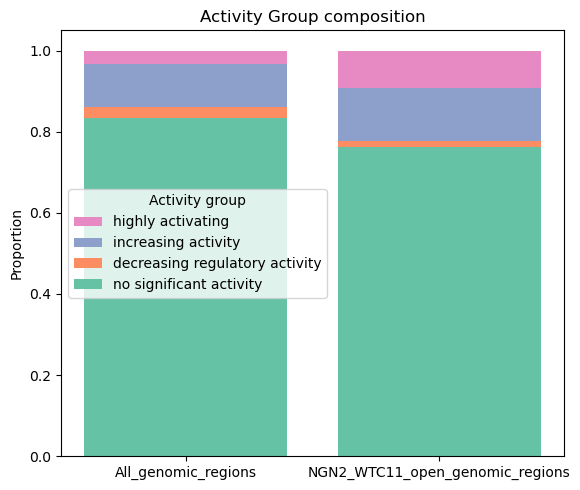

In [87]:
# plot: with no significant elements

# Compute normalized value counts
counts1 = mpra_80k_metadata_df_tested_bcalm_REF['plot_activity_group'].value_counts(normalize=True)
# counts2 = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF['plot_activity_group'].value_counts(normalize=True)
counts2 = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF['plot_activity_group'].value_counts(normalize=True)

# Combine into one DataFrame
combined = pd.DataFrame({'All_genomic_regions': counts1, 'NGN2_WTC11_open_genomic_regions': counts2}).fillna(0)



# Reorder for consistent stacking
desired_order = ['no significant activity', 'decreasing regulatory activity',
       'increasing activity', 'highly activating']
combined = combined.reindex(desired_order)
# Define a consistent color palette
group_colors = dict(zip(combined.index, sns.color_palette("Set2", n_colors=len(combined))))

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
bottoms = {'All_genomic_regions': 0, 'NGN2_WTC11_open_genomic_regions': 0}

for group in combined.index:
    ax.bar('All_genomic_regions', combined.loc[group, 'All_genomic_regions'], bottom=bottoms['All_genomic_regions'], color=group_colors[group], label=group)
    ax.bar('NGN2_WTC11_open_genomic_regions', combined.loc[group, 'NGN2_WTC11_open_genomic_regions'], bottom=bottoms['NGN2_WTC11_open_genomic_regions'], color=group_colors[group])
    bottoms['All_genomic_regions'] += combined.loc[group, 'All_genomic_regions']
    bottoms['NGN2_WTC11_open_genomic_regions'] += combined.loc[group, 'NGN2_WTC11_open_genomic_regions']

# # Only show one legend entry per group
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), title="Activity group")


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reverse the order
reversed_labels = list(by_label.keys())[::-1]
reversed_handles = [by_label[label] for label in reversed_labels]

ax.legend(reversed_handles,
          reversed_labels,
          title="Activity group",
          loc='center left',
          )


ax.set_ylabel("Proportion")
ax.set_title("Activity Group composition")
plt.tight_layout()
plt.show()

In [88]:
asdfasdf

NameError: name 'asdfasdf' is not defined

In [ ]:
mpra_80k_metadata_df_tested_bcalm_REF_filtered['plot_activity_group'].value_counts(normalize=True)

plot_activity_group
increasing activity               0.632809
highly activating                 0.200763
decreasing regulatory activity    0.166428
Name: proportion, dtype: float64

In [ ]:
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF_filtered['plot_activity_group'].value_counts(normalize=True)

plot_activity_group
highly activating                 0.698413
increasing activity               0.285714
decreasing regulatory activity    0.015873
Name: proportion, dtype: float64

In [ ]:
mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF_filtered.shape[0] # 279
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF_filtered.shape[0] # 126
mpra_80k_metadata_df_tested_bcalm_REF_filtered.shape[0] # 4194

4194

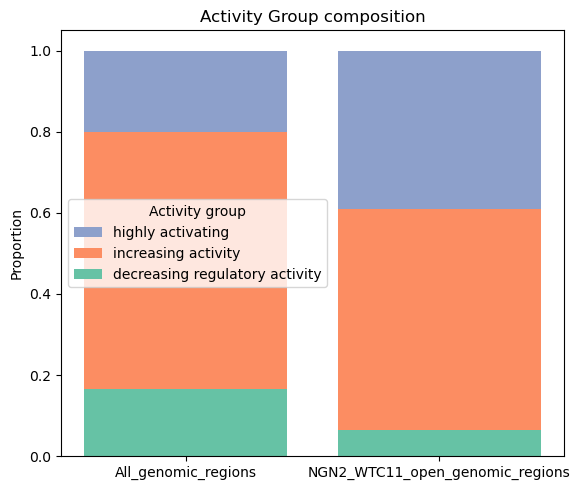

In [ ]:
# plot: without no significant elements
mpra_80k_metadata_df_tested_bcalm_REF_filtered = mpra_80k_metadata_df_tested_bcalm_REF.loc[mpra_80k_metadata_df_tested_bcalm_REF['activity_group'] != "no_activity"].copy()
mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF_filtered = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF.loc[mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF['activity_group'] != "no_activity"].copy()
mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF_filtered = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF.loc[mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF['activity_group'] != "no_activity"].copy()
# Compute normalized value counts
counts1 = mpra_80k_metadata_df_tested_bcalm_REF_filtered['plot_activity_group'].value_counts(normalize=True)
counts2 = mpra_80k_metadata_df_tested_bcalm_open_NGN2_wtc11_atac_REF_filtered['plot_activity_group'].value_counts(normalize=True)
counts2 = mpra_80k_metadata_df_tested_bcalm_neuro_CRE_REF_filtered['plot_activity_group'].value_counts(normalize=True)

# Combine into one DataFrame
combined = pd.DataFrame({'All_genomic_regions': counts1, 'NGN2_WTC11_open_genomic_regions': counts2}).fillna(0)

# Reorder for consistent stacking
desired_order = ['decreasing regulatory activity',
       'increasing activity', 'highly activating']
combined = combined.reindex(desired_order)
# Define a consistent color palette
group_colors = dict(zip(combined.index, sns.color_palette("Set2", n_colors=len(combined))))

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
bottoms = {'All_genomic_regions': 0, 'NGN2_WTC11_open_genomic_regions': 0}

for group in combined.index:
    ax.bar('All_genomic_regions', combined.loc[group, 'All_genomic_regions'], bottom=bottoms['All_genomic_regions'], color=group_colors[group], label=group)
    ax.bar('NGN2_WTC11_open_genomic_regions', combined.loc[group, 'NGN2_WTC11_open_genomic_regions'], bottom=bottoms['NGN2_WTC11_open_genomic_regions'], color=group_colors[group])
    bottoms['All_genomic_regions'] += combined.loc[group, 'All_genomic_regions']
    bottoms['NGN2_WTC11_open_genomic_regions'] += combined.loc[group, 'NGN2_WTC11_open_genomic_regions']

# # Only show one legend entry per group
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), title="Activity group")


handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Reverse the order
reversed_labels = list(by_label.keys())[::-1]
reversed_handles = [by_label[label] for label in reversed_labels]

ax.legend(reversed_handles,
          reversed_labels,
          title="Activity group",
          loc='center left',
          )


ax.set_ylabel("Proportion")
ax.set_title("Activity Group composition")
plt.tight_layout()
plt.show()

In [ ]:
asdfasdf

NameError: name 'asdfasdf' is not defined

investigate cre in neuro within all sequences vs only in active sequences

In [ ]:
mpra_80k_metadata_df_tested_bcalm['is_neuro_CRE'].value_counts()
mpra_80k_metadata_df_tested_bcalm['is_neuro_CRE'].value_counts(normalize=True) # 4.7 % of all
mpra_80k_metadata_df_tested_bcalm_REF['is_neuro_CRE'].value_counts(normalize=True) # 4.7 % of only references

is_neuro_CRE
False    0.953281
True     0.046719
Name: proportion, dtype: float64

In [ ]:
different_to_scrambled_activity_groups = ['scramble_less_active', 'high_active']
ngn2_mpra_80k_different_to_scrambled = mpra_80k_metadata_df_tested_bcalm.loc[mpra_80k_metadata_df_tested_bcalm['activity_group'].isin(different_to_scrambled_activity_groups)].copy()
ngn2_mpra_80k_different_to_neg_ctrl = mpra_80k_metadata_df_tested_bcalm.loc[~mpra_80k_metadata_df_tested_bcalm['activity_group'].isin(["no_activity"])].copy()

In [ ]:
print("Scrambled")
ngn2_mpra_80k_different_to_scrambled['is_neuro_CRE'].value_counts()
ngn2_mpra_80k_different_to_scrambled['is_neuro_CRE'].value_counts(normalize=True) # 10 % of all
ngn2_mpra_80k_different_to_scrambled_REF = ngn2_mpra_80k_different_to_scrambled.loc[~ngn2_mpra_80k_different_to_scrambled['name'].str.contains(":ALT_")].copy()
ngn2_mpra_80k_different_to_scrambled_REF['is_neuro_CRE'].value_counts(normalize=True) # 8.2 % of only references
ngn2_mpra_80k_different_to_scrambled_REF['is_neuro_CRE'].value_counts() # 8.2 % of only references
# ngn2_mpra_80k_different_to_scrambled_ALT = ngn2_mpra_80k_different_to_scrambled.loc[ngn2_mpra_80k_different_to_scrambled['name'].str.contains(":ALT_")].copy()
# ngn2_mpra_80k_different_to_scrambled_ALT['is_neuro_CRE'].value_counts(normalize=True) # 11 % of only references

# 1413 + 127 = 1540 ngn2_mpra_80k_different_to_scrambled_REF.shape[0]

Scrambled


1540

In [ ]:
print("Negative neuro controls")
ngn2_mpra_80k_different_to_neg_ctrl['is_neuro_CRE'].value_counts()
ngn2_mpra_80k_different_to_neg_ctrl['is_neuro_CRE'].value_counts(normalize=True) # 7.3 % of all
ngn2_mpra_80k_different_to_neg_ctrl_REF = ngn2_mpra_80k_different_to_neg_ctrl.loc[~ngn2_mpra_80k_different_to_neg_ctrl['name'].str.contains(":ALT_")].copy()
ngn2_mpra_80k_different_to_neg_ctrl_REF['is_neuro_CRE'].value_counts(normalize=True) # 6 % of only references
ngn2_mpra_80k_different_to_neg_ctrl_ALT = ngn2_mpra_80k_different_to_neg_ctrl.loc[ngn2_mpra_80k_different_to_neg_ctrl['name'].str.contains(":ALT_")].copy()
ngn2_mpra_80k_different_to_neg_ctrl_ALT['is_neuro_CRE'].value_counts(normalize=True) # 7 % of only references

Negative neuro controls


is_neuro_CRE
False    0.922106
True     0.077894
Name: proportion, dtype: float64

Distribution of activity from 

In [ ]:
ngn2_bcalm_negative_neuron_tested_bcalm.columns

Index(['name', 'sequence', 'category', 'class', 'source', 'ref', 'chr',
       'start', 'end', 'strand', 'variant_class', 'variant_pos', 'SPDI',
       'allele', 'info', 'bcalm_element_adjusted_p_value',
       'bcalm_element_log_ratio_activity', 'bcalm_data_exists', 'label',
       'activity_group', 'SCREEN_ID', 'is_neuro_CRE',
       'bcalm_element_log_ratio_activity_z_normalized',
       'bcalm_element_log_ratio_activity_not_normlized'],
      dtype='object')

In [ ]:
ngn2_bcalm_negative_neuron_tested_bcalm.columns
ngn2_bcalm_negative_neuron_tested_bcalm['is_neuro_CRE_label'] = ngn2_bcalm_negative_neuron_tested_bcalm_neg_ctrl_active['is_neuro_CRE'].apply(lambda is_neuro: "cCRE in NPC" if is_neuro else "not cCRE in NPC")
higher_than_neg_ctrl_activity = ['negative_control_active', 'high_active']

ngn2_bcalm_negative_neuron_tested_bcalm_neg_ctrl_active = ngn2_bcalm_negative_neuron_tested_bcalm.loc[ngn2_bcalm_negative_neuron_tested_bcalm['activity_group'].isin(higher_than_neg_ctrl_activity)].copy()
ngn2_bcalm_negative_neuron_tested_bcalm_neg_ctrl_active.shape[0]
ngn2_bcalm_negative_neuron_tested_bcalm_neg_ctrl_active['is_neuro_CRE_label'] = ngn2_bcalm_negative_neuron_tested_bcalm_neg_ctrl_active['is_neuro_CRE'].apply(lambda is_neuro: "cCRE in NPC" if is_neuro else "not cCRE in NPC")

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.ti

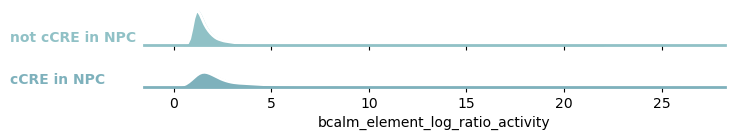

In [ ]:
# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
# g = sns.FacetGrid(ngn2_bcalm_negative_neuron_tested_bcalm_neg_ctrl_active, row="is_neuro_CRE_label", hue="is_neuro_CRE_label", aspect=15, height=.5, palette=pal)
g = sns.FacetGrid(ngn2_bcalm_negative_neuron_tested_bcalm, row="is_neuro_CRE_label", hue="is_neuro_CRE_label", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "bcalm_element_log_ratio_activity", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.23, 0.2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "bcalm_element_log_ratio_activity")

# Set the subplots to overlap
# g.figure.subplots_adjust(hspace=.00001)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
# plt.title("Activity of open and closed reginos in NGN2 derived WTC11 neurons")

In [ ]:
# how many different regions tested:
mpra_80k_metadata_df_tested.columns

# with strand and without strand:
number_strand_sensitive_regions = mpra_80k_metadata_df_tested.drop_duplicates(subset=['chr', 'start', 'end', 'strand']).shape[0] # 27556

number_regions_tested = mpra_80k_metadata_df_tested.drop_duplicates(subset=['chr', 'start', 'end']).shape[0]

print("Number of different tested regions:", number_regions_tested) # 27283

Number of different tested regions: 27283


In [ ]:
element_scrambled_path = "/home/kisa/coding/80K_MPRA/element_analysis_output/202502_element_analysis/NGN2_element_metadata_with_bcalm_2025_02_bbmap_vs_scrambled.tsv.gz"

In [ ]:
mpra_80k_metadata_df_tested

In [ ]:
import pandas as pd

table_cell_type_screen = pd.read_csv('/home/kisa/coding/80K_MPRA/cCREs_overlap/SCREEN_tissue/head_20_ENCFF414ORT_cell_type_for_SCREEN_ID.txt', sep="\t")

In [ ]:
table_cell_type_screen_annotation = table_cell_type_screen.loc[table_cell_type_screen['rDHS'].str.startswith("rDHS")]

table_cell_type_screen

,rDHS,ENCSR000EID,ENCSR000EIF,ENCSR000EIG,ENCSR000EII,ENCSR000EIJ,ENCSR000EIK,ENCSR000EIL,ENCSR000EIN,ENCSR000EIO,...,ENCSR987CQN,ENCSR987GUS,ENCSR988YKR,ENCSR989YIV,ENCSR990XXC,ENCSR994KTY,ENCSR995YPS,ENCSR998IXQ,ENCSR999TSD,ENCSR999VDH
0,rDHS,Homo_sapiens_8988T_ENCDO000ACP,Homo_sapiens_naive_thymus-derived_CD4-positive...,Homo_sapiens_T-helper_1_cell_ENCDO174AAA,Homo_sapiens_B_cell_female_adult_27_years_ENCD...,Homo_sapiens_cerebellum_tissue_male_adult_27_y...,Homo_sapiens_frontal_cortex_tissue_male_adult_...,Homo_sapiens_chorion_tissue_ENCDO180AAA,Homo_sapiens_COLO829_ENCDO000ACS,Homo_sapiens_Ishikawa_treated_with_10_nM_17β-e...,...,Homo_sapiens_posterior_cingulate_gyrus_tissue_...,Homo_sapiens_stimulated_activated_CD4-positive...,Homo_sapiens_kidney_capillary_endothelial_cell...,Homo_sapiens_placenta_tissue_male_embryo_91_da...,Homo_sapiens_right_kidney_tissue_male_embryo_1...,Homo_sapiens_colonic_mucosa_tissue_female_adul...,Homo_sapiens_with_mild_cognitive_impairment_mi...,Homo_sapiens_stimulated_activated_CD4-positive...,Homo_sapiens_coronary_artery_tissue_female_adu...,Homo_sapiens_pancreas_tissue_female_adult_59_y...
1,EH38D0001261,0.00518125,0.0188695,0.0592075,0.0430536,0.141614,0.0773561,0.00212685,0.0469768,0.0494198,...,0.0965742,0.0316948,0.151049,0.0889357,0.0841212,0.116711,0.156214,0.0351685,0.17945,0.0357827
2,EH38D0001472,0.274323,0.258824,0.36851,0.429307,0.59261,1.20802,0.904128,0.0999752,0.148977,...,1.11435,0.146102,0,0.0904124,0.152207,0.207906,0.426155,0.127494,0.146191,0.188801
3,EH38D0002482,0.242207,0.127832,0.301083,0.219127,0.0391648,0.229597,0.349841,0.0724392,0.137385,...,0.305069,0.122185,0.0372554,0.0381578,0.029445,0.228345,0.16791,0.0978031,0.223567,0.39308
4,EH38D0004910,0.0877408,0.0755882,0.015978,0.079572,0.155232,0.0632668,0.0237297,0.0448501,0.0573586,...,0.15267,0.0394712,0.0334998,0.00369704,0.0937341,0.0827987,0.106566,0.06074,0.137191,0.0487327
5,EH38D0006760,0.0215875,0.0329456,0.00823859,0.0521983,0.0253584,0.0155252,0.0312023,0.0262558,0.0334135,...,0.0609319,0.0382048,0.0424811,0.0153368,0.0488995,0.120704,0.078364,0.0257573,0.0816993,0.0733992
6,EH38D0009140,0.0410984,0.158311,0.118465,0.161882,0.0501718,0.0947256,0.236321,0.0482224,0.109161,...,0.0456617,0.0769851,0.0152002,0.054614,0.040137,0.159848,0.0976744,0.00710517,0.121129,0.0922835
7,EH38D0011504,0.0759836,0.0532258,0.0700798,0.0769432,0.0890913,0.0995492,0.0754187,0.0534165,0.0495179,...,0.0745702,0.0454051,0.0687742,0.185236,0.036487,0.128835,0.0987612,0.0775032,0.104846,0.0418704
8,EH38D0011545,0.137256,0.142946,0.0771558,0.0841729,0.0692054,0.0884136,0.155344,0.0787252,0.0684007,...,0.0764453,0.0215611,0.0275717,0.0879191,0.00685383,0.147862,0.171457,0.0880538,0.112521,0.0416808
9,EH38D0016750,0.163768,0.254353,0.119274,0.0828743,0.131103,0.0816714,0.24577,0.05789,0.148916,...,0.035564,0.0254601,0.0481167,0.132859,0.0341374,0.0553101,0.0547396,0.01812,0.066531,0.0118473


In [ ]:
table_cell_type_screen_annotation

In [ ]:
# include the header row and filter the given cell-type specific read-deepth normalized signal table down
(head -n 1 ENCFF617DFU.tsv && grep -F -f ids.tsv ENCFF617DFU.tsv) > filtered_activity.tsv

In [ ]:
# TODO: clean the header and plot the row specific data distribution of 5 examples